<a href="https://www.kaggle.com/code/wilfriedtsetse04/neurosight-ai-notebook?scriptVersionId=300807538" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [4]:
import os
import sys
import matplotlib.pyplot as plt

# --- 1. LE REMÈDE ANTI-CRASH PYTORCH (OBLIGATOIRE EN PREMIER) ---
import torch
# On force PyTorch à charger ses modules CUDA tout de suite
_ = torch.cuda.is_available() 
print(f"✅ PyTorch {torch.__version__} est réveillé et prêt.")

# --- 2. TÉLÉCHARGEMENT DE TA LIBRAIRIE ---
# J'utilise la branche dev-leila2 comme sur tes précédentes captures. 
# Si tu as fusionné sur main, remplace 'dev-leila2' par 'main' dans l'URL.
GITHUB_RAW_URL = "https://raw.githubusercontent.com/wekt2k04/NeuroSight_AI/dev-leila2/notebooks/data_pipeline.py"

print("📥 Téléchargement de data_pipeline.py...")
!wget -q -O data_pipeline.py {GITHUB_RAW_URL}

if '/kaggle/working' not in sys.path:
    sys.path.append('/kaggle/working')

# --- 3. IMPORTATION ---
try:
    # Nettoyage du cache au cas où tu relances la cellule
    if 'data_pipeline' in sys.modules:
        import importlib
        importlib.reload(sys.modules['data_pipeline'])
        
    from data_pipeline import get_dataloaders, show_sample_batch
    print("✅ Fichier data_pipeline.py importé avec succès sans crash !")
except Exception as e:
    print(f"❌ Erreur : {e}")

# --- 4. LE NOUVEAU DATASET ---
# Basé sur ta capture d'écran, voici le chemin exact
DATA_DIR = '/kaggle/input/datasets/wilfriedtsetse04/neurosight-ai-dataset/neurosight-mri-dataset/OriginalDataset'

if os.path.exists(DATA_DIR):
    print(f"📂 Dataset trouvé à l'adresse : {DATA_DIR}")
else:
    print(f"❌ ERREUR : Dataset introuvable. As-tu bien fait '+ Add Input' dans Kaggle ?")

✅ PyTorch 2.9.0+cu126 est réveillé et prêt.
📥 Téléchargement de data_pipeline.py...
✅ Fichier data_pipeline.py importé avec succès sans crash !
📂 Dataset trouvé à l'adresse : /kaggle/input/datasets/wilfriedtsetse04/neurosight-ai-dataset/neurosight-mri-dataset/OriginalDataset


🚀 Usine à données prête ! Classes détectées : ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']


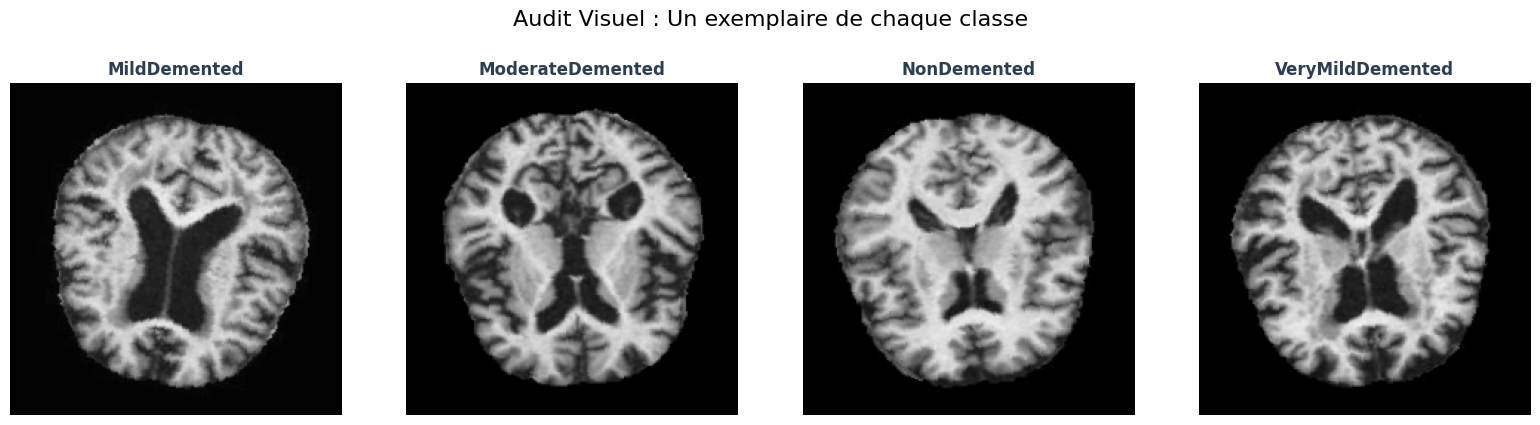

In [6]:
# ==========================================
# CELLULE 2 : CRÉATION DES LOADERS & VISUALISATION DE CHAQUE CLASSE
# ==========================================
import matplotlib.pyplot as plt
import torch

# 1. Création des DataLoaders à partir de ton dataset privé
DATA_DIR = '/kaggle/input/datasets/wilfriedtsetse04/neurosight-ai-dataset/neurosight-mri-dataset/OriginalDataset'

# On appelle la fonction de notre librairie pour générer l'usine à données
train_loader, test_loader, classes = get_dataloaders(DATA_DIR, batch_size=32)

print(f"🚀 Usine à données prête ! Classes détectées : {classes}")

# 2. Récupérer le premier lot (batch) d'images
images, labels = next(iter(train_loader))

# Dénormalisation pour l'affichage (Annuler les maths de PyTorch pour nos yeux)
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
images = images * std + mean
images = torch.clamp(images, 0, 1) # Sécurité pour éviter les pixels aberrants

# 3. Extraire et afficher exactement UNE image par classe
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
classes_trouvees = set()

# On fouille dans le lot de 32 images...
for img, label in zip(images, labels):
    nom_classe = classes[label]
    
    # ... et si on tombe sur une classe qu'on n'a pas encore affichée :
    if nom_classe not in classes_trouvees:
        index = len(classes_trouvees)
        ax = axes[index]
        
        # Affichage de l'image (Transformation CHW -> HWC)
        ax.imshow(img.permute(1, 2, 0).numpy())
        ax.set_title(nom_classe, fontsize=12, fontweight='bold', color='#2c3e50')
        ax.axis('off')
        
        classes_trouvees.add(nom_classe)
        
        # Si on a trouvé un exemplaire des 4 classes, on arrête de fouiller
        if len(classes_trouvees) == 4:
            break

plt.suptitle("Audit Visuel : Un exemplaire de chaque classe", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()